In [2]:
import pandas as pd
import numpy as np
from datetime import datetime, timedelta
from IPython.display import display

import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import LabelEncoder
from sklearn.cluster import KMeans

In [3]:
Med_insurance_data = pd.read_csv("/Users/aurelienterral/Downloads/medical_insurance.csv", delimiter=',')

display(Med_insurance_data.head())


pd.set_option('display.max_columns', None)
display(Med_insurance_data.sample(10))
display(Med_insurance_data.describe())
# display(Med_insurance_data.columns.tolist())

,person_id,age,sex,region,urban_rural,income,education,marital_status,employment_status,household_size,...,liver_disease,arthritis,mental_health,proc_imaging_count,proc_surgery_count,proc_physio_count,proc_consult_count,proc_lab_count,is_high_risk,had_major_procedure
0,75722,52,Female,North,Suburban,22700.0,Doctorate,Married,Retired,3,...,0,1,0,1,0,2,0,1,0,0
1,80185,79,Female,North,Urban,12800.0,No HS,Married,Employed,3,...,0,1,1,0,0,1,0,1,1,0
2,19865,68,Male,North,Rural,40700.0,HS,Married,Retired,5,...,0,0,1,1,0,2,1,0,1,0
3,76700,15,Male,North,Suburban,15600.0,Some College,Married,Self-employed,5,...,0,0,0,1,0,0,1,0,0,0
4,92992,53,Male,Central,Suburban,89600.0,Doctorate,Married,Self-employed,2,...,0,1,0,2,0,1,1,0,1,0


,person_id,age,sex,region,urban_rural,income,education,marital_status,employment_status,household_size,dependents,bmi,smoker,alcohol_freq,visits_last_year,hospitalizations_last_3yrs,days_hospitalized_last_3yrs,medication_count,systolic_bp,diastolic_bp,ldl,hba1c,plan_type,network_tier,deductible,copay,policy_term_years,policy_changes_last_2yrs,provider_quality,risk_score,annual_medical_cost,annual_premium,monthly_premium,claims_count,avg_claim_amount,total_claims_paid,chronic_count,hypertension,diabetes,asthma,copd,cardiovascular_disease,cancer_history,kidney_disease,liver_disease,arthritis,mental_health,proc_imaging_count,proc_surgery_count,proc_physio_count,proc_consult_count,proc_lab_count,is_high_risk,had_major_procedure
82303,20194,17,Male,East,Urban,48800.0,No HS,Married,Unemployed,2,0,29.6,Never,Occasional,3,0,0,1,110.0,67.0,118.0,5.16,POS,Gold,2000,20,10,0,5.00,0.1978,3182.03,678.21,56.52,0,0.00,0.00,1,0,0,1,0,0,0,0,0,0,0,0,0,0,1,1,0,0
31583,65189,27,Female,North,Urban,30500.0,Some College,Married,Retired,2,0,32.1,Never,Occasional,2,0,0,0,110.0,61.0,161.6,5.63,PPO,Platinum,1000,10,2,0,3.36,0.1868,1440.98,460.73,38.39,1,480.48,480.48,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
979,45567,71,Male,North,Urban,60300.0,Masters,Single,Retired,2,1,26.8,Never,Weekly,3,0,0,0,118.0,68.0,68.6,5.58,PPO,Platinum,1000,10,8,0,4.23,0.7802,1029.23,389.09,32.42,2,326.33,652.66,1,0,0,0,0,0,0,0,0,0,1,0,0,0,1,0,1,0
90876,67195,40,Female,North,Rural,12000.0,Masters,Single,Retired,2,1,22.2,Never,Occasional,1,0,0,2,117.0,76.0,170.2,5.35,POS,Silver,500,20,1,0,3.74,0.4396,1207.30,349.88,29.16,2,406.36,812.72,1,1,0,0,0,0,0,0,0,0,0,2,0,0,1,0,0,0
7211,11721,44,Other,Central,Suburban,34100.0,No HS,Married,Employed,4,2,31.4,Never,Daily,0,0,0,1,124.0,73.0,107.3,4.93,PPO,Bronze,2000,20,9,0,4.13,0.3736,1891.76,401.61,33.47,0,0.00,0.00,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0
86235,61402,21,Female,North,Urban,77800.0,HS,Married,Employed,5,3,26.9,Never,NaN,1,0,0,2,95.0,53.0,74.5,5.75,HMO,Gold,5000,50,1,0,2.90,0.2308,2979.56,679.06,56.59,2,1374.44,2748.88,1,0,0,0,0,0,0,0,0,0,1,1,0,0,0,0,0,0
55260,78218,34,Male,South,Suburban,18300.0,Some College,Married,Employed,2,0,29.0,Never,Occasional,1,0,0,0,100.0,65.0,131.1,5.82,PPO,Gold,1000,10,7,0,1.91,0.1758,710.07,312.25,26.02,1,321.04,321.04,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0
99633,3421,38,Female,South,Urban,50400.0,HS,Married,Retired,3,1,29.6,Never,Weekly,4,0,0,2,109.0,59.0,136.5,8.10,POS,Bronze,500,30,8,0,3.36,0.4176,2518.68,446.79,37.23,1,1411.95,1411.95,1,0,1,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0
89975,9968,47,Male,South,Urban,25700.0,Bachelors,Married,Employed,2,0,27.5,Never,NaN,0,0,0,0,123.0,76.0,106.2,5.14,HMO,Silver,1000,10,9,0,3.47,0.3187,747.77,299.73,24.98,0,0.00,0.00,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,2,0,0
48952,85347,43,Female,Central,Suburban,17800.0,Some College,Married,Retired,2,0,28.2,Current,NaN,1,0,0,0,102.0,72.0,120.4,5.20,HMO,Platinum,1000,10,5,0,4.23,0.5494,1247.74,427.11,35.59,1,477.19,477.19,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


,person_id,age,income,household_size,dependents,bmi,visits_last_year,hospitalizations_last_3yrs,days_hospitalized_last_3yrs,medication_count,systolic_bp,diastolic_bp,ldl,hba1c,deductible,copay,policy_term_years,policy_changes_last_2yrs,provider_quality,risk_score,annual_medical_cost,annual_premium,monthly_premium,claims_count,avg_claim_amount,total_claims_paid,chronic_count,hypertension,diabetes,asthma,copd,cardiovascular_disease,cancer_history,kidney_disease,liver_disease,arthritis,mental_health,proc_imaging_count,proc_surgery_count,proc_physio_count,proc_consult_count,proc_lab_count,is_high_risk,had_major_procedure
count,100000.000000,100000.000000,1.000000e+05,100000.000000,100000.000000,100000.000000,100000.00000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.00000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.00000,100000.000000,100000.000000,100000.000000
mean,50000.500000,47.521500,4.987390e+04,2.430900,0.898380,26.990512,1.92765,0.093640,0.373350,1.236320,117.808970,73.604770,119.975065,5.605968,1226.725000,19.520400,5.517760,0.050690,3.598920,0.519849,3009.451907,582.320040,48.526668,1.62178,656.512084,1377.878827,0.724720,0.203450,0.085930,0.058870,0.035950,0.051170,0.021510,0.014620,0.014770,0.108310,0.130140,0.508530,0.158690,0.508390,0.50933,0.509140,0.367810,0.169700
std,28867.657797,15.988752,4.680021e+04,1.075126,0.950654,4.994883,1.73773,0.304848,1.373011,1.209358,15.369187,8.900924,30.262086,0.845996,1019.619375,10.286255,2.868827,0.224591,0.594052,0.250669,3127.462822,399.583722,33.298640,2.02982,1072.660048,2305.464687,0.805523,0.402566,0.280262,0.235382,0.186166,0.220345,0.145078,0.120027,0.120632,0.310773,0.336459,0.749755,0.463562,0.747218,0.75363,0.750455,0.482212,0.375371
min,1.000000,0.000000,1.100000e+03,1.000000,0.000000,12.000000,0.00000,0.000000,0.000000,0.000000,61.000000,40.000000,30.000000,3.540000,500.000000,10.000000,1.000000,0.000000,1.500000,0.000000,55.550000,211.670000,17.640000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000
25%,25000.750000,37.000000,2.110000e+04,2.000000,0.000000,23.600000,1.00000,0.000000,0.000000,0.000000,107.000000,67.000000,99.400000,5.160000,500.000000,10.000000,3.000000,0.000000,3.200000,0.329700,1175.117500,352.070000,29.340000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000
50%,50000.500000,48.000000,3.620000e+04,2.000000,1.000000,27.000000,2.00000,0.000000,0.000000,1.000000,117.000000,73.000000,120.000000,5.440000,1000.000000,20.000000,6.000000,0.000000,3.600000,0.505500,2082.575000,463.585000,38.630000,1.00000,318.015000,642.545000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000
75%,75000.250000,58.000000,6.220000e+04,3.000000,1.000000,30.400000,3.00000,0.000000,0.000000,2.000000,128.000000,79.000000,140.300000,5.760000,2000.000000,30.000000,8.000000,0.000000,4.010000,0.703300,3707.957500,666.697500,55.560000,2.00000,872.215000,1795.522500,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,1.000000,1.00000,1.000000,1.000000,0.000000
max,100000.000000,100.000000,1.061800e+06,9.000000,7.000000,50.400000,25.00000,3.000000,21.000000,11.000000,183.000000,114.000000,248.300000,11.940000,5000.000000,50.000000,10.000000,2.000000,5.000000,1.000000,65724.9000

In [4]:
plan_metrics = Med_insurance_data.groupby(['plan_type', 'network_tier'], observed=False).agg({
    'annual_medical_cost': ['sum', 'mean'], # Assuming this is Billed Amount Sum/AVG
    'total_claims_paid': ['sum', 'mean'], # Claims Paid amount Sum/AVG
    'copay': ['sum', 'mean'], # Member Copay Sum/AVG
    'deductible': ['sum', 'mean'], # Member Deductible Sum/AVG
    'annual_premium': ['sum', 'mean'], # Annual Premium Sum/AVG
    'claims_count': ['sum', 'mean'], ## Claims Count/AVG per Member
    'person_id': ['count'] # Member Count
})

# Cleanup columns
plan_metrics.columns = ['_'.join(col).strip() for col in plan_metrics.columns.values]
plan_metrics_final = plan_metrics.reset_index()

plan_metrics_final['loss_ratio'] = plan_metrics_final['total_claims_paid_sum'] / plan_metrics_final['annual_premium_sum'] # Bad Loss ratio - for every dollar on premiums, more is spent
plan_metrics_final['Total_Member_Paid'] = plan_metrics_final['copay_sum'] + plan_metrics_final['deductible_sum']   
plan_metrics_final['Charges vs Claims Paid Difference'] = plan_metrics_final['annual_medical_cost_sum'] - plan_metrics_final['total_claims_paid_sum'] # Difference bettwen Billed and Paid claim amount
plan_metrics_final['Dollar_Loss_Per_Member'] = plan_metrics_final['total_claims_paid_mean'] - plan_metrics_final['annual_premium_mean'] # On AVG what is the $$ value per member

network_tier_order = ['Bronze', 'Silver', 'Gold', 'Platinum']

# Use network tier order above to set order
plan_metrics_final['network_tier'] = pd.Categorical(
    plan_metrics_final['network_tier'], 
    categories=network_tier_order, 
    ordered=True
)

# Sort by plan type then network tier
plan_metrics_final = plan_metrics_final.sort_values(by=['plan_type', 'network_tier'])

display(plan_metrics_final)

,plan_type,network_tier,annual_medical_cost_sum,annual_medical_cost_mean,total_claims_paid_sum,total_claims_paid_mean,copay_sum,copay_mean,deductible_sum,deductible_mean,annual_premium_sum,annual_premium_mean,claims_count_sum,claims_count_mean,person_id_count,loss_ratio,Total_Member_Paid,Charges vs Claims Paid Difference,Dollar_Loss_Per_Member
0,EPO,Bronze,13503039.45,3004.013226,6141712.04,1366.343057,88240,19.630701,5431000,1208.231368,2249601.72,500.467568,7283,1.620245,4495,2.730133,5519240,7361327.41,865.875488
3,EPO,Silver,17996741.39,2998.957072,8223150.36,1370.296677,117790,19.628395,7490500,1248.208632,3434714.26,572.356984,9879,1.646226,6001,2.394129,7608290,9773591.03,797.939693
1,EPO,Gold,9117071.04,2983.334764,4167959.75,1363.861175,59280,19.397906,3794000,1241.492147,1961998.37,642.015173,4867,1.592605,3056,2.124344,3853280,4949111.29,721.846001
2,EPO,Platinum,4659929.46,2969.999656,2126927.09,1355.594066,30160,19.222435,1835500,1169.853410,1142982.74,728.478483,2563,1.633525,1569,1.860857,1865660,2533002.37,627.115583
4,HMO,Bronze,31802950.93,3049.472714,14452842.31,1385.832037,203200,19.484131,12791500,1226.531786,5266798.36,505.014705,17036,1.633522,10429,2.744142,12994700,17350108.62,880.817331
7,HMO,Silver,42492202.34,3024.356038,19728819.64,1404.186451,272420,19.389324,17143500,1220.177936,8080499.89,575.124547,23142,1.647117,14050,2.441535,17415920,22763382.70,829.061904
5,HMO,Gold,20149657.83,2967.112035,9341345.25,1375.547821,132410,19.497865,8378000,1233.691651,4343530.55,639.601023,10963,1.614343,6791,2.150634,8510410,10808312.58,735.946797
6,HMO,Platinum,10211373.96,2957.247020,4667366.09,1351.684359,67040,19.415001,4275500,1238.198668,2510133.81,726.942893,5562,1.610773,3453,1.859409,4342540,5544007.87,624.741465
8,POS,Bronze,13302661.46,2964.051127,6033842.52,1344.439064,87340,19.460784,5668500,1263.034759,2231340.53,497.179262,6995,1.558601,4488,2.704133,5755840,7268818.94,847.259802
11,POS,Silver,18189421.99,3043.236070,8384759.02,1402.837380,117500,19.658692,7330500,1226.451397,3451435.84,577.452876,9729,1.627740,5977,2.429354,7448000,9804662.97,825.384504


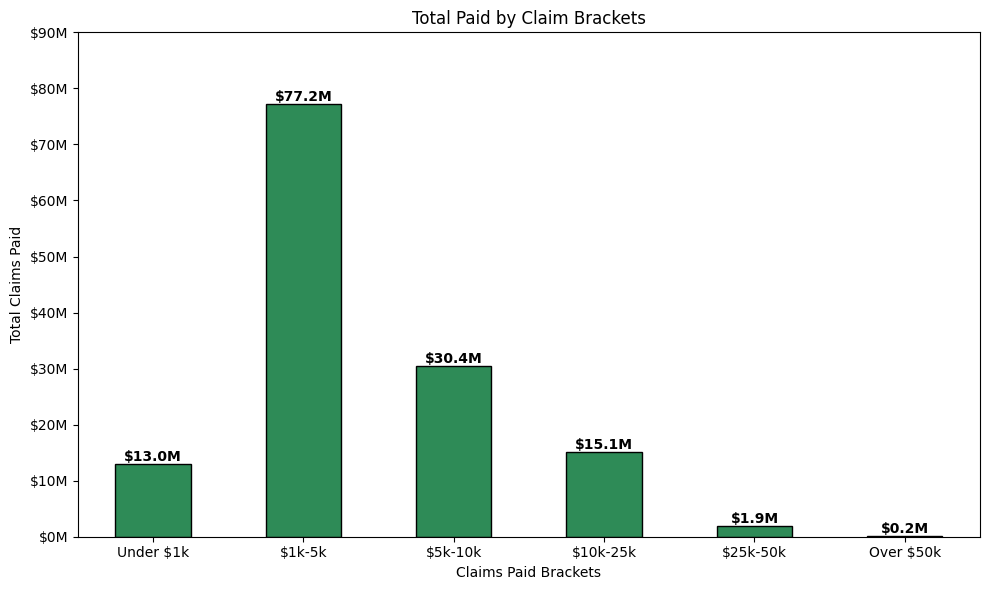

In [5]:
# Analysis of Total Claims paid by bucket 
 
# Creating Brackets
bins = [0, 1000, 5000, 10000, 25000, 50000, 100000]
labels = ['Under $1k', '$1k-5k', '$5k-10k', '$10k-25k', '$25k-50k', 'Over $50k']

# Group and sum, plot
Med_insurance_data['bracket'] = pd.cut(Med_insurance_data["total_claims_paid"], bins=bins, labels=labels)
total_spent = Med_insurance_data.groupby('bracket', observed=False)['total_claims_paid'].sum()
ax = total_spent.plot(kind='bar', color='seagreen', edgecolor='black', figsize=(10, 6))

# Update Y axis to only have the first 2 digits and M for the total dollars for readability, code divides by 1 M and puts $ in front
ticks = plt.gca().get_yticks()
plt.gca().set_yticks(ticks) # Fixes the locations
plt.gca().set_yticklabels([f'${x/1e6:,.0f}M' for x in ticks])

# Add Data labels to Bars (with same code as above for $$$)
for i, v in enumerate(total_spent):
    plt.text(i, v, f'${v/1e6:,.1f}M', ha='center', va='bottom', fontweight='bold')

plt.xlabel("Claims Paid Brackets")
plt.ylabel("Total Claims Paid")
plt.title("Total Paid by Claim Brackets")
plt.xticks(rotation=0) # Keeps bracket names horizontal
plt.tight_layout()
plt.show()

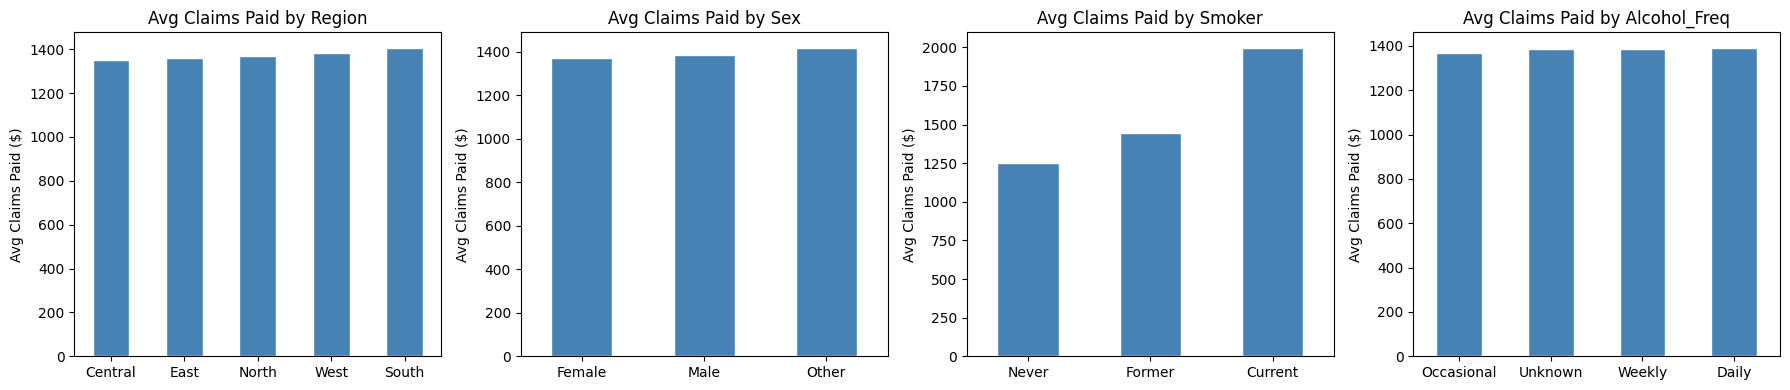

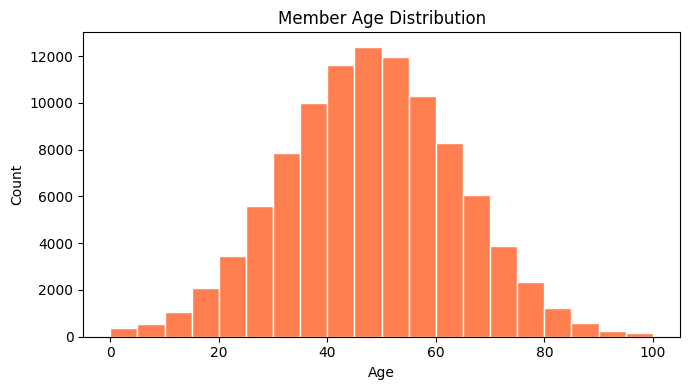

In [6]:
# Renaming Null (NaN) values as "Unkown"

Med_insurance_data['smoker'] = Med_insurance_data['smoker'].fillna("Unknown")
Med_insurance_data['alcohol_freq'] = Med_insurance_data['alcohol_freq'].fillna("Unknown")

# A couple of sublots
fig, axes = plt.subplots(1, 4, figsize=(18, 4))
 
for ax, col in zip(axes, ["region", "sex", "smoker","alcohol_freq"]):
    avg = Med_insurance_data.groupby(col)["total_claims_paid"].mean().sort_values()
    avg.plot(kind="bar", ax=ax, color="steelblue", edgecolor="white")
    ax.set_title(f"Avg Claims Paid by {col.title()}")
    ax.set_xlabel("")
    ax.set_ylabel("Avg Claims Paid ($)")
    ax.tick_params(axis="x", rotation=0)
 
plt.tight_layout()
plt.show()
 
# Age Distribution by Members
plt.figure(figsize=(7, 4))
plt.hist(Med_insurance_data["age"], bins=20, color="coral", edgecolor="white")
plt.title("Member Age Distribution")
plt.xlabel("Age")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

In [7]:

# Checking the "Other" values in the sex column
# Other_data = Med_insurance_data[~Med_insurance_data['sex'].isin(['Male', 'Female'])]
# print(Other_data['sex'].value_counts(dropna=False))

print(Med_insurance_data['sex'].unique())

# Values by Sex
print(Med_insurance_data['sex'].value_counts(dropna=False))



['Female' 'Male' 'Other']
sex
Female    49193
Male      48794
Other      2013
Name: count, dtype: int64


Total Claims Paid by Gender:
Female: $67,447,449.65
Male: $67,485,390.03
Other: $2,855,042.99


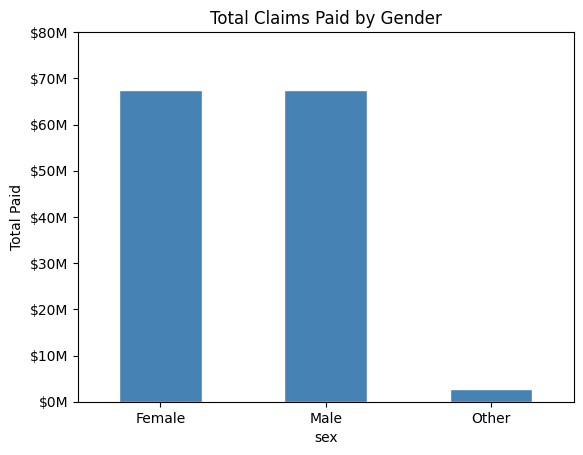

In [8]:
gender_totals = Med_insurance_data.groupby('sex', observed=False)['total_claims_paid'].sum()

# Total Paid by Gender
print("Total Claims Paid by Gender:")
for gender, total in gender_totals.items():
    print(f"{gender}: ${total:,.2f}")

ax = gender_totals.plot(kind='bar', color='steelblue', edgecolor='white')

ticks = ax.get_yticks()
ax.set_yticks(ticks) 
ax.set_yticklabels([f'${x/1e6:,.0f}M' for x in ticks])

plt.ylabel("Total Paid")
plt.title("Total Claims Paid by Gender")
plt.xticks(rotation=0)
plt.show()

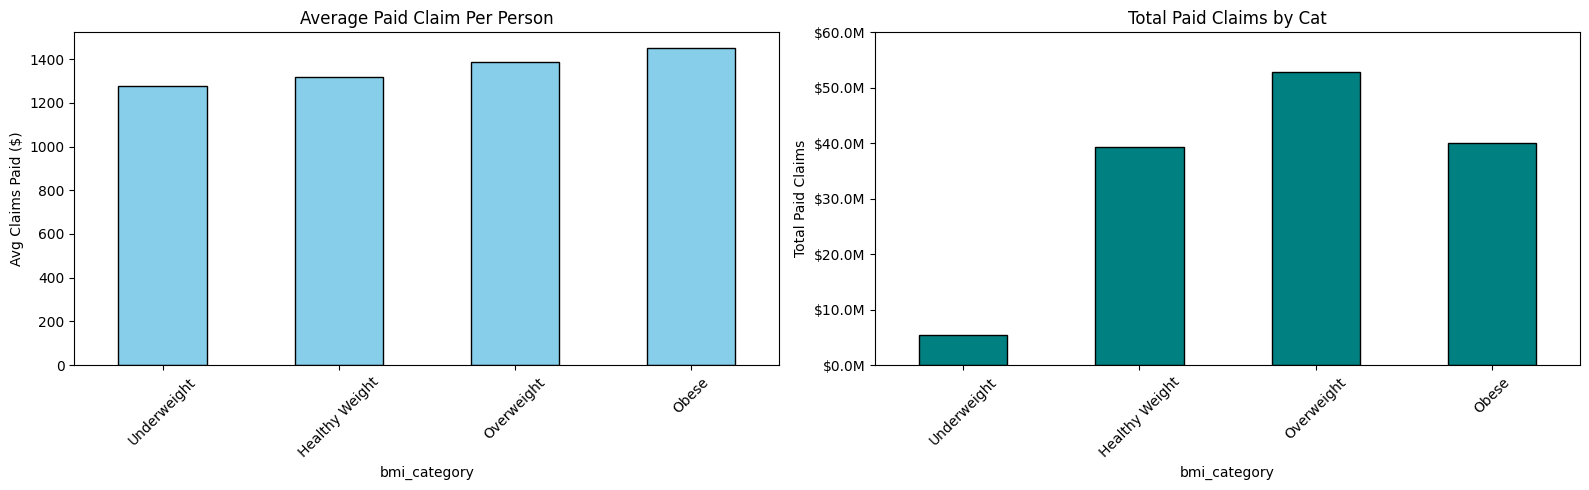

In [9]:
# print(Med_insurance_data['bmi'].describe())
# Create BMI Categories using bins

bins = [0, 18.5, 25, 30, np.inf]
labels = ['Underweight', 'Healthy Weight', 'Overweight', 'Obese']

Med_insurance_data['bmi_category'] = pd.cut(Med_insurance_data['bmi'], bins=bins, labels=labels, right=False)


bmi_avg = Med_insurance_data.groupby('bmi_category', observed=False)['total_claims_paid'].mean()
bmi_total = Med_insurance_data.groupby('bmi_category', observed=False)['total_claims_paid'].sum()

# subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))

# 1st Graph AVG per person by BMI Cat
bmi_avg.plot(kind='bar', ax=ax1, color='skyblue', edgecolor='black')
ax1.set_title("Average Paid Claim Per Person")
ax1.set_ylabel("Avg Claims Paid ($)")
ax1.set_xticklabels(labels, rotation=45)

# Total Cost in paid claims by BMI Cat
bmi_total.plot(kind='bar', ax=ax2, color='teal', edgecolor='black')
ax2.set_title("Total Paid Claims by Cat")
ax2.set_ylabel("Total Paid Claims")

# $$$ formating
ticks = ax2.get_yticks()
ax2.set_yticks(ticks)
ax2.set_yticklabels([f'${x/1e6:,.1f}M' for x in ticks])
ax2.set_xticklabels(labels, rotation=45)

plt.tight_layout()
plt.show()

Top 10 Features Correlated with Risk Score
is_high_risk              0.821276
age                       0.720989
chronic_count             0.666014
systolic_bp               0.553843
diastolic_bp              0.379526
hypertension              0.346731
visits_last_year          0.313346
claims_count              0.311008
annual_medical_cost       0.305971
total_claims_paid         0.305782
monthly_premium           0.295860
annual_premium            0.295859
mental_health             0.285307
arthritis                 0.265102
medication_count          0.264541
diabetes                  0.233629
avg_claim_amount          0.199926
asthma                    0.193422
hba1c                     0.183235
cardiovascular_disease    0.177263
Name: risk_score, dtype: float64


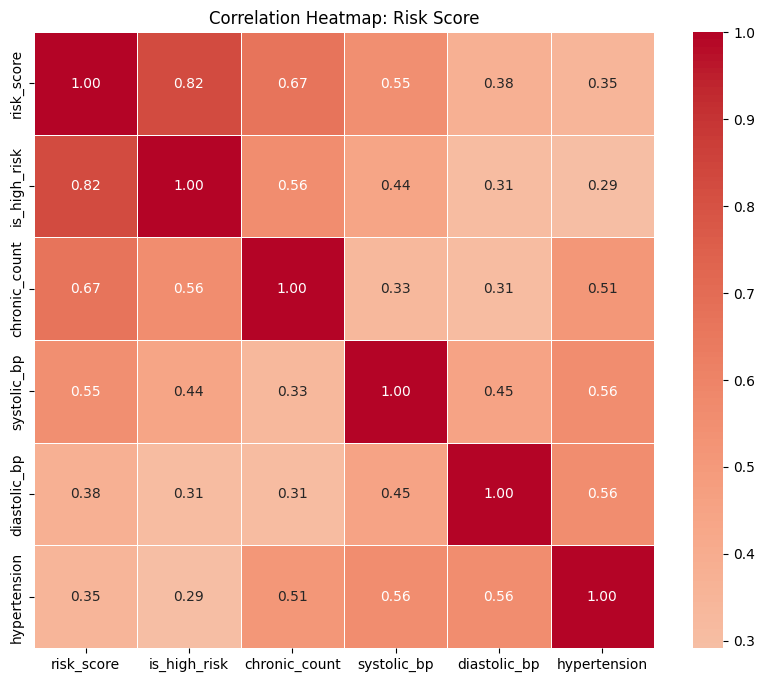

In [10]:
corr_matrix = Med_insurance_data.corr(numeric_only=True)

risk_correlation = corr_matrix['risk_score'].drop('risk_score')

top10_features = risk_correlation.abs().sort_values(ascending=False).head(20)

output = risk_correlation[top10_features.index]

print("Top 10 Features Correlated with Risk Score")
print(output)


heatmap = ['risk_score','is_high_risk', 'chronic_count','systolic_bp','diastolic_bp','hypertension']
corr_matrix = Med_insurance_data[heatmap].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, 
            annot=True,     
            cmap='coolwarm',    
            center=0,       
            fmt='.2f',       
            linewidths=0.5)

plt.title('Correlation Heatmap: Risk Score')
plt.show()

In [11]:
print(Med_insurance_data.groupby('is_high_risk')['risk_score'].agg(['count', 'mean', 'min', 'max']))

              count      mean     min     max
is_high_risk                                 
0             63219  0.362822  0.0000  0.5934
1             36781  0.789747  0.6044  1.0000


- Below we are doing data analysis on members with high risk and chronic counts >=1 but have risk scores below the mean. We could certainly change this threshold to be median or 25th percentile. Researching for low risk score members where the health plan would have an opportunity to find members with chronic conditions and low risk scores.


In [12]:
# Threshold
# 
AVG_score = Med_insurance_data['risk_score'].mean()

# People who are NOT high risk but have above AVG scores
missed_high_scores = Med_insurance_data[(Med_insurance_data['is_high_risk'] == 0) & (Med_insurance_data['risk_score'] > AVG_score)]

# People who ARE high risk but have below AVG scores
low_score_high_risk = Med_insurance_data[(Med_insurance_data['is_high_risk'] == 1) & (Med_insurance_data['risk_score'] < AVG_score)]

# People who are NOT chronic but have above AVG scores
missed_chronic_scores = Med_insurance_data[(Med_insurance_data['chronic_count'] == 0) & (Med_insurance_data['risk_score'] > AVG_score)]

# People who ARE chronic but have below AVG scores
low_score_chronic_risk = Med_insurance_data[(Med_insurance_data['chronic_count'] >= 1) & (Med_insurance_data['risk_score'] < AVG_score)]


# People who are NOT systolic_bp but have above AVG scores
missed_systolic_bp_scores = Med_insurance_data[(Med_insurance_data['systolic_bp'] < 130) & (Med_insurance_data['risk_score'] > AVG_score)]

# People who ARE systolic_bp but have below AVG scores
low_score_systolic_bp_risk = Med_insurance_data[(Med_insurance_data['systolic_bp'] >= 130) & (Med_insurance_data['risk_score'] < AVG_score)] # systolic_bp is considered a clinical cutoff


print(f"High scores not flagged as high risk: {len(missed_high_scores)}")
print(f"High risk flags with low scores: {len(low_score_high_risk)}")

print(f"High scores not flagged as chronic: {len(missed_chronic_scores)}")
print(f"Chronic Count >=1 flags with low scores: {len(low_score_chronic_risk)}")

print(f"High scores not flagged as systolic: {len(missed_systolic_bp_scores)}")
print(f"systolic Count >=1 flags with low scores: {len(low_score_systolic_bp_risk)}")


High scores not flagged as high risk: 10673
High risk flags with low scores: 0
High scores not flagged as chronic: 9277
Chronic Count >=1 flags with low scores: 15291
High scores not flagged as systolic: 29715
systolic Count >=1 flags with low scores: 4003


In [13]:
display(missed_high_scores.head(10))

,person_id,age,sex,region,urban_rural,income,education,marital_status,employment_status,household_size,dependents,bmi,smoker,alcohol_freq,visits_last_year,hospitalizations_last_3yrs,days_hospitalized_last_3yrs,medication_count,systolic_bp,diastolic_bp,ldl,hba1c,plan_type,network_tier,deductible,copay,policy_term_years,policy_changes_last_2yrs,provider_quality,risk_score,annual_medical_cost,annual_premium,monthly_premium,claims_count,avg_claim_amount,total_claims_paid,chronic_count,hypertension,diabetes,asthma,copd,cardiovascular_disease,cancer_history,kidney_disease,liver_disease,arthritis,mental_health,proc_imaging_count,proc_surgery_count,proc_physio_count,proc_consult_count,proc_lab_count,is_high_risk,had_major_procedure,bracket,bmi_category
0,75722,52,Female,North,Suburban,22700.0,Doctorate,Married,Retired,3,1,27.4,Never,Unknown,2,0,0,4,121.0,76.0,123.8,5.28,PPO,Bronze,1000,20,4,0,3.73,0.5714,6938.06,876.05,73.00,1,4672.59,4672.59,1,0,0,0,0,0,0,0,0,1,0,1,0,2,0,1,0,0,$1k-5k,Overweight
10,27702,34,Female,South,Urban,98900.0,Masters,Divorced,Employed,2,1,18.8,Never,Occasional,8,0,0,3,113.0,65.0,111.4,4.96,POS,Silver,2000,20,10,0,3.99,0.5714,10011.08,1421.33,118.44,11,656.93,7226.23,2,0,0,0,0,0,0,0,0,1,1,0,0,1,0,0,0,0,$5k-10k,Healthy Weight
24,41332,42,Female,North,Rural,26900.0,Bachelors,Married,Retired,4,2,30.9,Never,Weekly,0,0,0,2,121.0,81.0,160.5,5.76,EPO,Silver,5000,10,9,0,3.87,0.5494,6941.62,1082.99,90.25,0,0.00,0.00,1,0,0,0,1,0,0,0,0,0,0,1,0,1,1,1,0,0,NaN,Obese
36,69770,63,Female,West,Urban,49200.0,HS,Single,Employed,1,0,33.0,Never,Unknown,2,0,0,0,118.0,79.0,93.9,5.55,HMO,Silver,1000,10,3,0,2.89,0.5824,1217.49,356.10,29.68,2,356.87,713.74,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,Under $1k,Obese
43,31777,42,Male,Central,Suburban,17100.0,No HS,Single,Employed,2,1,32.2,Never,Weekly,0,0,0,1,157.0,79.0,111.6,5.10,HMO,Silver,2000,30,9,0,3.41,0.5494,1857.47,442.90,36.91,0,0.00,0.00,1,1,0,0,0,0,0,0,0,0,0,1,1,0,2,0,0,1,NaN,Obese
45,79157,43,Male,North,Urban,41300.0,Bachelors,Married,Self-employed,3,1,36.2,Never,Occasional,1,0,0,1,130.0,88.0,89.7,5.38,POS,Bronze,1000,10,4,0,3.42,0.5604,776.97,284.59,23.72,0,0.00,0.00,1,1,0,0,0,0,0,0,0,0,0,0,1,1,2,0,0,1,NaN,Obese
53,70552,72,Male,North,Rural,53800.0,HS,Widowed,Employed,4,3,23.1,Never,Weekly,3,0,0,0,122.0,84.0,76.7,5.21,HMO,Bronze,1000,20,6,0,4.27,0.5934,3603.56,555.94,46.33,2,819.79,1639.58,0,0,0,0,0,0,0,0,0,0,0,1,0,0,1,0,0,0,$1k-5k,Healthy Weight
71,30960,59,Female,East,Urban,123400.0,Masters,Single,Employed,1,0,31.9,Never,Occasional,1,0,0,1,123.0,57.0,134.9,5.39,HMO,Silver,1000,10,1,0,4.38,0.5385,1502.89,390.35,32.53,2,680.81,1361.62,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,1,$1k-5k,Obese
84,86412,62,Female,South,Urban,33900.0,Bachelors,Married,Self-employed,3,1,34.4,Former,Weekly,2,0,0,0,139.0,67.0,158.3,5.22,EPO,Bronze,500,20,3,0,2.23,0.5714,1961.20,393.28,32.77,0,0.00,0.00,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,NaN,Obese
86,53930,51,Male,South,Suburban,33800.0,Bachelors,Married,Employed,2,0,19.4,Never,Weekly,0,0,0,0,107.0,69.0,135.5,5.20,PPO,Gold,1000,10,10,1,3.60,0.5604,1056.47,362.13,30.18,0,0.00,0.00,1,0,0,1,0,0,0,0,0,0,0,0,1,1,1,2,0,1,NaN,Healthy Weight


In [14]:
display(low_score_systolic_bp_risk.head(10))

,person_id,age,sex,region,urban_rural,income,education,marital_status,employment_status,household_size,dependents,bmi,smoker,alcohol_freq,visits_last_year,hospitalizations_last_3yrs,days_hospitalized_last_3yrs,medication_count,systolic_bp,diastolic_bp,ldl,hba1c,plan_type,network_tier,deductible,copay,policy_term_years,policy_changes_last_2yrs,provider_quality,risk_score,annual_medical_cost,annual_premium,monthly_premium,claims_count,avg_claim_amount,total_claims_paid,chronic_count,hypertension,diabetes,asthma,copd,cardiovascular_disease,cancer_history,kidney_disease,liver_disease,arthritis,mental_health,proc_imaging_count,proc_surgery_count,proc_physio_count,proc_consult_count,proc_lab_count,is_high_risk,had_major_procedure,bracket,bmi_category
46,51686,36,Male,West,Urban,110400.0,Some College,Single,Retired,1,0,22.3,Never,Unknown,2,0,0,2,133.0,64.0,127.8,6.01,HMO,Silver,1000,10,8,0,2.88,0.1978,689.05,292.69,24.39,1,253.40,253.40,0,0,0,0,0,0,0,0,0,0,0,0,0,2,0,1,0,0,Under $1k,Healthy Weight
57,73692,55,Female,South,Rural,13400.0,Bachelors,Married,Employed,3,1,36.4,Former,Weekly,2,0,0,2,142.0,61.0,119.5,5.39,HMO,Bronze,5000,20,2,1,3.78,0.4945,1022.31,348.14,29.01,0,0.00,0.00,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,NaN,Obese
92,15664,49,Female,East,Suburban,92100.0,Some College,Married,Employed,4,2,24.5,Never,Occasional,3,0,0,0,133.0,78.0,125.4,4.82,HMO,Silver,500,20,7,0,4.19,0.3407,849.13,306.90,25.58,1,557.66,557.66,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,Under $1k,Healthy Weight
102,82364,44,Female,North,Rural,164400.0,HS,Married,Self-employed,2,0,21.5,Former,Occasional,2,0,0,3,148.0,90.0,115.0,5.43,PPO,Silver,500,30,10,0,4.55,0.4835,928.57,316.43,26.37,1,607.10,607.10,1,1,0,0,0,0,0,0,0,0,0,2,0,0,1,1,0,0,Under $1k,Healthy Weight
107,13936,41,Other,West,Rural,33200.0,HS,Married,Employed,3,1,28.7,Never,Occasional,4,0,0,1,141.0,80.0,97.7,4.42,HMO,Bronze,5000,20,8,0,3.18,0.4505,5559.23,783.69,65.31,2,1212.33,2424.66,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,$1k-5k,Overweight
113,55224,49,Female,East,Suburban,14200.0,Bachelors,Married,Retired,3,1,20.3,Never,Unknown,0,0,0,1,134.0,67.0,123.3,4.94,POS,Silver,1000,30,5,0,3.99,0.3407,1611.71,403.41,33.62,0,0.00,0.00,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,3,0,0,NaN,Healthy Weight
140,5224,33,Male,South,Urban,27000.0,No HS,Married,Employed,3,1,23.3,Never,Unknown,1,0,0,1,139.0,85.0,112.8,4.79,POS,Silver,1000,10,8,0,3.28,0.3626,1009.12,331.09,27.59,1,691.86,691.86,1,1,0,0,0,0,0,0,0,0,0,0,0,0,1,1,0,0,Under $1k,Healthy Weight
144,34305,31,Male,West,Urban,88800.0,Bachelors,Single,Employed,2,1,32.7,Never,Occasional,2,1,1,4,137.0,71.0,92.9,5.81,PPO,Gold,1000,30,2,0,3.72,0.4286,2568.83,579.91,48.33,4,614.20,2456.80,1,1,0,0,0,0,0,0,0,0,0,1,0,0,1,1,0,0,$1k-5k,Obese
169,49188,35,Female,West,Suburban,13300.0,No HS,Single,Employed,1,0,35.2,Former,Weekly,2,0,0,2,135.0,79.0,122.0,5.71,EPO,Gold,1000,10,6,0,3.37,0.4725,3091.11,655.12,54.59,2,1350.91,2701.82,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,$1k-5k,Obese
203,35074,40,Female,East,Urban,11800.0,Some College,Single,Unemployed,1,0,24.7,Never,Unknown,4,0,0,0,139.0,75.0,129.5,5.05,PPO,Silver,500,20,10,0,4.21,0.4396,3863.14,668.58,55.72,2,1727.80,3455.60,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,$1k-5k,Healthy Weight


In [15]:
display(missed_systolic_bp_scores.head(10))

,person_id,age,sex,region,urban_rural,income,education,marital_status,employment_status,household_size,dependents,bmi,smoker,alcohol_freq,visits_last_year,hospitalizations_last_3yrs,days_hospitalized_last_3yrs,medication_count,systolic_bp,diastolic_bp,ldl,hba1c,plan_type,network_tier,deductible,copay,policy_term_years,policy_changes_last_2yrs,provider_quality,risk_score,annual_medical_cost,annual_premium,monthly_premium,claims_count,avg_claim_amount,total_claims_paid,chronic_count,hypertension,diabetes,asthma,copd,cardiovascular_disease,cancer_history,kidney_disease,liver_disease,arthritis,mental_health,proc_imaging_count,proc_surgery_count,proc_physio_count,proc_consult_count,proc_lab_count,is_high_risk,had_major_procedure,bracket,bmi_category
0,75722,52,Female,North,Suburban,22700.0,Doctorate,Married,Retired,3,1,27.4,Never,Unknown,2,0,0,4,121.0,76.0,123.8,5.28,PPO,Bronze,1000,20,4,0,3.73,0.5714,6938.06,876.05,73.00,1,4672.59,4672.59,1,0,0,0,0,0,0,0,0,1,0,1,0,2,0,1,0,0,$1k-5k,Overweight
10,27702,34,Female,South,Urban,98900.0,Masters,Divorced,Employed,2,1,18.8,Never,Occasional,8,0,0,3,113.0,65.0,111.4,4.96,POS,Silver,2000,20,10,0,3.99,0.5714,10011.08,1421.33,118.44,11,656.93,7226.23,2,0,0,0,0,0,0,0,0,1,1,0,0,1,0,0,0,0,$5k-10k,Healthy Weight
24,41332,42,Female,North,Rural,26900.0,Bachelors,Married,Retired,4,2,30.9,Never,Weekly,0,0,0,2,121.0,81.0,160.5,5.76,EPO,Silver,5000,10,9,0,3.87,0.5494,6941.62,1082.99,90.25,0,0.00,0.00,1,0,0,0,1,0,0,0,0,0,0,1,0,1,1,1,0,0,NaN,Obese
36,69770,63,Female,West,Urban,49200.0,HS,Single,Employed,1,0,33.0,Never,Unknown,2,0,0,0,118.0,79.0,93.9,5.55,HMO,Silver,1000,10,3,0,2.89,0.5824,1217.49,356.10,29.68,2,356.87,713.74,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,Under $1k,Obese
39,16131,50,Male,North,Suburban,23000.0,Bachelors,Married,Employed,4,2,27.8,Never,Occasional,1,0,0,2,127.0,89.0,171.8,4.76,PPO,Bronze,500,20,2,0,3.78,0.7473,5171.90,701.50,58.46,2,1284.36,2568.72,2,1,0,0,1,0,0,0,0,0,0,0,0,1,1,1,1,0,$1k-5k,Overweight
42,40164,84,Female,North,Urban,26500.0,Bachelors,Married,Retired,2,0,20.9,Current,Occasional,3,0,0,1,129.0,72.0,151.9,5.00,HMO,Silver,2000,50,1,0,3.41,1.0000,1703.79,424.45,35.37,2,672.61,1345.22,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,$1k-5k,Healthy Weight
44,25331,71,Male,West,Urban,89100.0,Bachelors,Single,Unemployed,1,0,16.5,Never,Occasional,4,0,0,2,112.0,64.0,108.9,4.78,POS,Silver,500,10,6,0,3.61,0.7802,801.93,301.23,25.10,2,201.89,403.78,1,0,0,1,0,0,0,0,0,0,0,4,0,0,0,0,1,0,Under $1k,Underweight
53,70552,72,Male,North,Rural,53800.0,HS,Widowed,Employed,4,3,23.1,Never,Weekly,3,0,0,0,122.0,84.0,76.7,5.21,HMO,Bronze,1000,20,6,0,4.27,0.5934,3603.56,555.94,46.33,2,819.79,1639.58,0,0,0,0,0,0,0,0,0,0,0,1,0,0,1,0,0,0,$1k-5k,Healthy Weight
66,60056,51,Female,South,Suburban,43800.0,Bachelors,Single,Employed,1,0,26.2,Never,Occasional,2,0,0,4,123.0,76.0,107.2,5.08,POS,Bronze,500,30,9,0,3.84,0.7582,1414.53,340.79,28.40,2,501.29,1002.58,2,0,0,0,0,0,0,0,0,1,1,0,0,2,0,2,1,0,$1k-5k,Overweight
67,45949,61,Male,South,Urban,74500.0,Some College,Married,Employed,3,1,23.3,Former,Unknown,2,0,0,0,111.0,71.0,63.4,8.00,PPO,Silver,1000,30,8,0,4.19,0.6703,11644.96,1607.40,133.95,2,3460.54,6921.08,1,0,1,0,0,0,0,0,0,0,0,2,0,0,0,1,1,0,$5k-10k,Healthy Weight


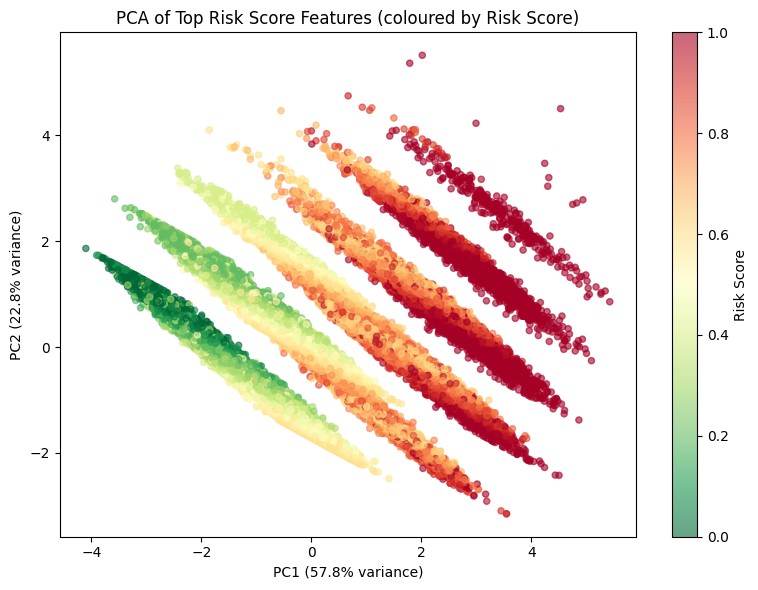

PC1 explains: 57.8%
PC2 explains: 22.8%
Total variance explained: 80.7%
----------------------------------------
                    PC1       PC2
is_high_risk   0.563059  0.188846
age            0.497735 -0.559956
chronic_count  0.421531  0.754059
systolic_bp    0.507480 -0.286674


,income,bmi,systolic_bp,diastolic_bp,ldl,hba1c,provider_quality,annual_medical_cost,annual_premium,avg_claim_amount,total_claims_paid
0,-0.580636,0.081982,0.207625,0.269099,0.126394,-0.385307,0.220654,1.256165,0.735090,3.744036,1.429088
1,-0.792174,-0.078182,0.858278,0.606143,-0.749290,-0.929045,-0.839859,-0.440242,-0.343407,-0.334908,-0.081892
2,-0.196023,0.902822,2.745170,1.167882,0.314748,-0.113438,0.506824,1.487326,2.391739,-0.612041,-0.597658
3,-0.732345,0.922842,-0.898484,-0.629684,1.332523,3.420860,0.489990,0.678127,0.596396,-0.612041,-0.597658
4,0.848844,0.702617,1.183604,1.055534,1.686101,-0.479870,0.506824,-0.418461,-0.203687,0.322309,-0.162934
...,...,...,...,...,...,...,...,...,...,...,...
99995,1.652259,0.242145,-0.182766,0.044403,-0.577457,-0.739918,0.557324,-0.548180,-0.633159,-0.612041,-0.597658
99996,-0.604141,0.122022,-1.093680,-0.854380,1.887673,0.063868,0.574158,-0.498078,-0.395687,-0.612041,-0.597658
99997,0.684315,0.562473,0.663082,1.055534,-0.038830,-0.101617,0.910828,-0.229724,-0.118674,-0.320653,0.486931
99998,-0.138331,-1.019145,-0.508093,-0.067945,0.493189,-0.420768,-1.412199,-0.553066,-0.599274,-0.097078,-0.118466


In [16]:
# Principal Component Analysis (PCA) for risk scores in the Medical Insurance Dataset for the top 3 correlated features 

from sklearn.decomposition import PCA as PCA

# Checking Nulls
# print(med_normalized.dropna().shape)

# Analyzing these 3 features (based off top correlation > .50)
features = ['is_high_risk', 'age','chronic_count', 'systolic_bp']
x = Med_insurance_data[features].dropna()
risk_scores = Med_insurance_data.loc[x.index, 'risk_score']

# Scaling
x_scaled = (x - x.mean()) / x.std()

# Doing a PCA with and without the scaler

pca_model = PCA(n_components=2)
risk_components = pca_model.fit_transform(x_scaled)

# Plot
plt.figure(figsize=(8,6))

scatter = plt.scatter(risk_components [:, 0], risk_components[:, 1],
                      c=risk_scores, cmap='RdYlGn_r', alpha=0.6, s=20)
plt.colorbar(scatter, label='Risk Score')
plt.title('PCA of Top Risk Score Features (coloured by Risk Score)')
plt.xlabel(f'PC1 ({pca_model.explained_variance_ratio_[0]*100:.1f}% variance)')
plt.ylabel(f'PC2 ({pca_model.explained_variance_ratio_[1]*100:.1f}% variance)')
plt.tight_layout()
plt.show()

print(f"PC1 explains: {pca_model.explained_variance_ratio_[0]*100:.1f}%")
print(f"PC2 explains: {pca_model.explained_variance_ratio_[1]*100:.1f}%")
print(f"Total variance explained: {sum(pca_model.explained_variance_ratio_)*100:.1f}%")

print("----"*10)

# Shows weights per feature within PC1 and PC2
loadings = pd.DataFrame(
    pca_model.components_.T, 
    columns=['PC1', 'PC2'], 
    index=features
)
print(loadings)

# Another PCA analysis on every feature in the dataset except risk score and monthly premium
PCA_columns = [col for col in Med_insurance_data.columns 
               if Med_insurance_data[col].dtype == 'float64'
                and col not in ['risk_score', 'monthly_premium']]

med_normalized = (Med_insurance_data[PCA_columns] - Med_insurance_data[PCA_columns].mean()) / Med_insurance_data[PCA_columns].std()

med_normalized_PCA = PCA(n_components=5) 
med_normalized_PCA.fit(med_normalized.dropna())
med_components = pd.DataFrame(med_normalized_PCA.components_, columns=PCA_columns)
med_normalized


- PC1 is driven by is_high_risk and chronic_Count
- PC2 is systolic_bp

In [17]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Define Features (sticking with top 4 correlated) and Target (risk score)
features = ['is_high_risk', 'age', 'chronic_count', 'systolic_bp']
x = Med_insurance_data[features].dropna()
y = Med_insurance_data.loc[x.index, 'risk_score']

# Split into Training and Testing sets 80/20 
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

# Initialize and Train model
reg_model = LinearRegression()
reg_model.fit(x_train, y_train)

# Predict Risk Score
y_pred = reg_model.predict(x_test)

# Validate the models quality (R2 Loss)
print(f"R-squared: {r2_score(y_test, y_pred):.2f}")

# MSE 
print(f"MSE: {mean_squared_error(y_test, y_pred)}")

R-squared: 0.89
MSE: 0.006892144866998457


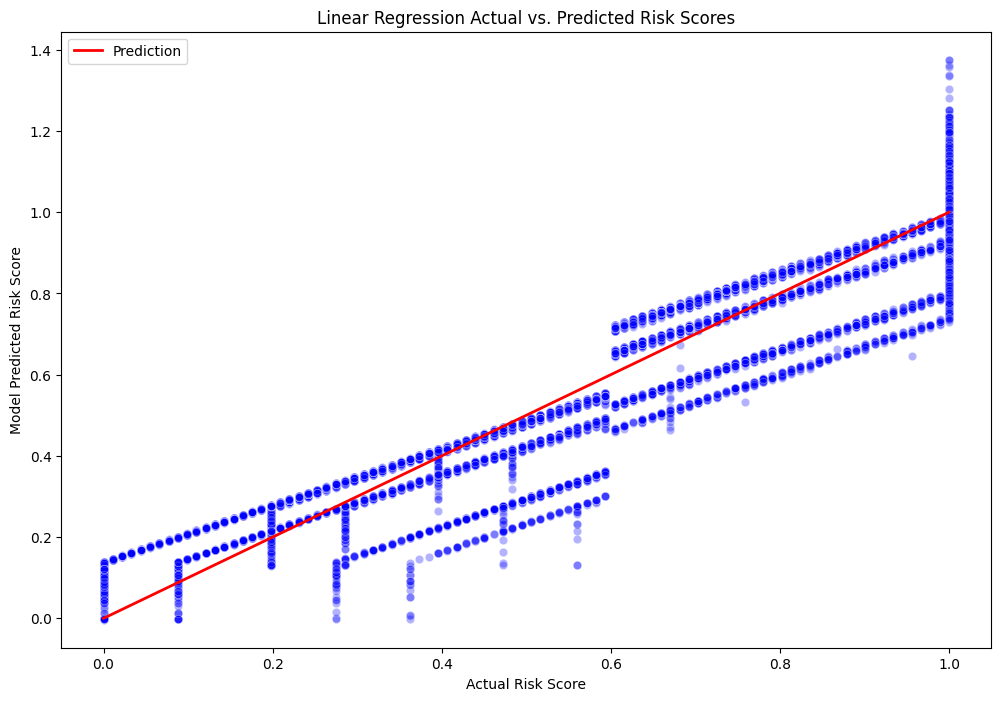

In [18]:
# Plot the Linear Regression Acutal vs predicted risk scores

plt.figure(figsize=(12, 8))
sns.scatterplot(x=y_test, y=y_pred, alpha=0.3, color='blue')

# Adding Regression Line
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 
         'r-', lw=2, label='Prediction')

plt.title('Linear Regression Actual vs. Predicted Risk Scores')
plt.xlabel('Actual Risk Score')
plt.ylabel('Model Predicted Risk Score')
plt.legend()
plt.show()

In [21]:
# Random Forest Regression Analysis

# Define Features (sticking with top 4 correlated) and Target (risk score)
features = ['is_high_risk', 'age', 'chronic_count', 'systolic_bp']
x = Med_insurance_data[features].dropna()
y = Med_insurance_data.loc[x.index, 'risk_score']

# Split into training and testing sets 80/20 
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

# Initialize and train model
reg_model = RandomForestRegressor()
reg_model.fit(x_train, y_train)

# Predict Risk Score
y_pred = reg_model.predict(x_test)

# Validate the models quality (R2 Loss)
print(f"R-squared: {r2_score(y_test, y_pred):.2f}")

# MSE 
print(f"MSE: {mean_squared_error(y_test, y_pred)}")

R-squared: 0.91
MSE: 0.005954598707894987


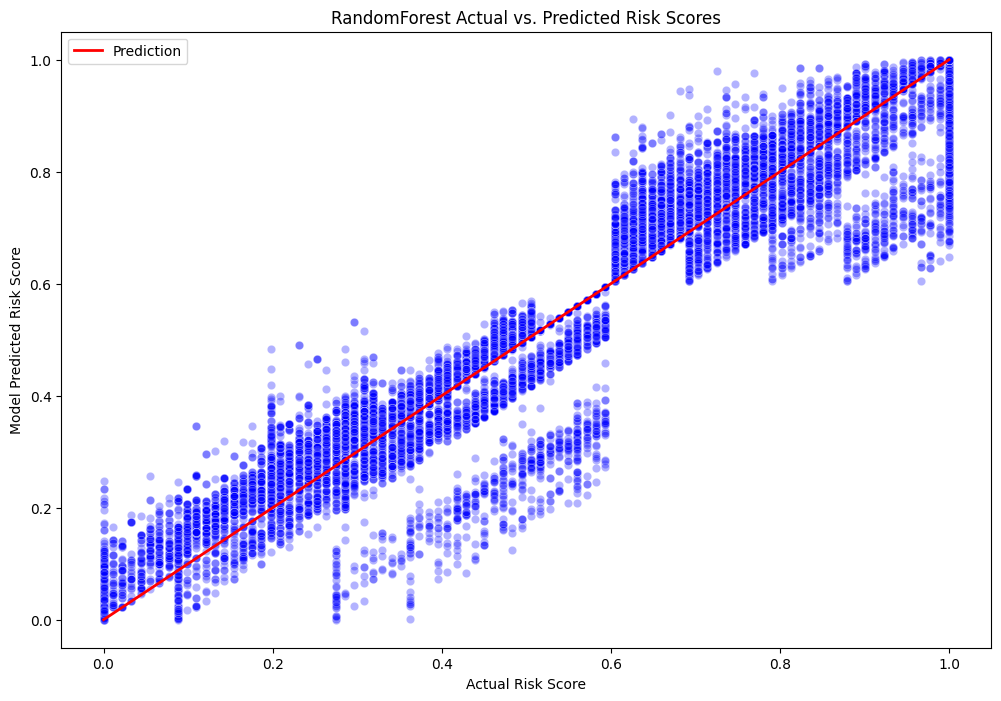

In [22]:
# Plot the Acutal vs predicted risk scores

plt.figure(figsize=(12, 8))
sns.scatterplot(x=y_test, y=y_pred, alpha=0.3, color='blue')

# Adding Regression Line
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 
         'r-', lw=2, label='Prediction')

plt.title('RandomForest Actual vs. Predicted Risk Scores')
plt.xlabel('Actual Risk Score')
plt.ylabel('Model Predicted Risk Score')
plt.legend()
plt.show()

In [ ]:
importances = pd.Series(reg_model.feature_importances_, index=X.columns)
print(importances.sort_values(ascending=False))

is_high_risk     0.716006
age              0.165426
chronic_count    0.100319
systolic_bp      0.018249
dtype: float64
